In [42]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.ndimage import gaussian_filter
centers = [(0, 10), (0, 100), (-70, 70), (-100, 0), (-70, -70), (0, -100), (70, -70), (100, 0), (70, 70)]
#centers = [(-2, 11), (-3, 96), (-71, 68), (-99, 0), (-71, -69), (-3, -97), (65, -70), (93, -2), (66, 67)]
def plot_sens(img, centers, gauss_sigma = 0, savedir = None):
    img = img.astype(np.float32)
    if gauss_sigma > 0:
        img = gaussian_filter(img, sigma=gauss_sigma)
    dim, vox = (360, 360, 110), (1, 1, 1)

    img = np.mean(img[:,:,:], axis = 2).T
    img = img / np.max(img[180-10:180+10, 180-10:180+10])
    plt.figure(figsize=(10, 10))
    plt.imshow(img, extent=[-180, 180, -180, 180], cmap = 'jet', vmax = 1)
    print(np.min(img), np.max(img))
    sens2 = []
    centersens2 = 0
    s = 20
    for (x, y) in centers:    
        xplt, yplt = x // vox[0], y // vox[1]
        #print(np.sum(img[x + 180 - s//2:x + 180 + s//2, y + 180 - s//2:y + 180 + s//2]))
        plt.plot([x - s/2, x + s/2], [y - s/2, y - s/2], 'r-', linewidth=2)
        plt.plot([x + s/2, x + s/2], [y - s/2, y + s/2], 'r-', linewidth=2)
        plt.plot([x + s/2, x - s/2], [y + s/2, y + s/2], 'r-', linewidth=2)
        plt.plot([x - s/2, x - s/2], [y + s/2, y - s/2], 'r-', linewidth=2)
        sens = np.mean(img[yplt + dim[1]//2-s//2:yplt + dim[1]//2+s//2, xplt + dim[0]//2-s//2:xplt + dim[0]//2+s//2])
        if centersens2 == 0:
            centersens2 = sens
        plt.text(  
            x, y - s/2 - 10,
            f'{sens / centersens2:.4f}',
            fontsize=12, ha='center', va='center',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
        )
        sens2.append(sens / centersens2)
    plt.grid(True, color='white', linewidth=0.4)
    #print(centersens2, sens2)
    cbar = plt.colorbar(shrink=0.75, label='Relative sensitivity', pad = 0.01)
    cbar.set_label('Relative sensitivity', rotation=270, labelpad=20)
    plt.xlabel('x (mm)')
    plt.ylabel('y (mm)')
    if savedir is not None:
        plt.savefig(os.path.join(savedir), dpi = 300, bbox_inches = 'tight')
    plt.show()
    return centersens2, sens2

In [16]:
img1 = np.fromfile(os.path.join('sensimgs/siddon.bin'), dtype = np.float64).reshape(360, 360, order = 'F').T
img2 = np.fromfile(os.path.join('sensimgs/mc.bin'), dtype = np.float64).reshape(360, 360, order = 'F').T


3860.2413641671596
2692.17795859927
2924.882802878633
1857.533745797621
2924.882802878633
2692.17795859927
2924.8828076011678
1857.5337925809094
2924.882807601167


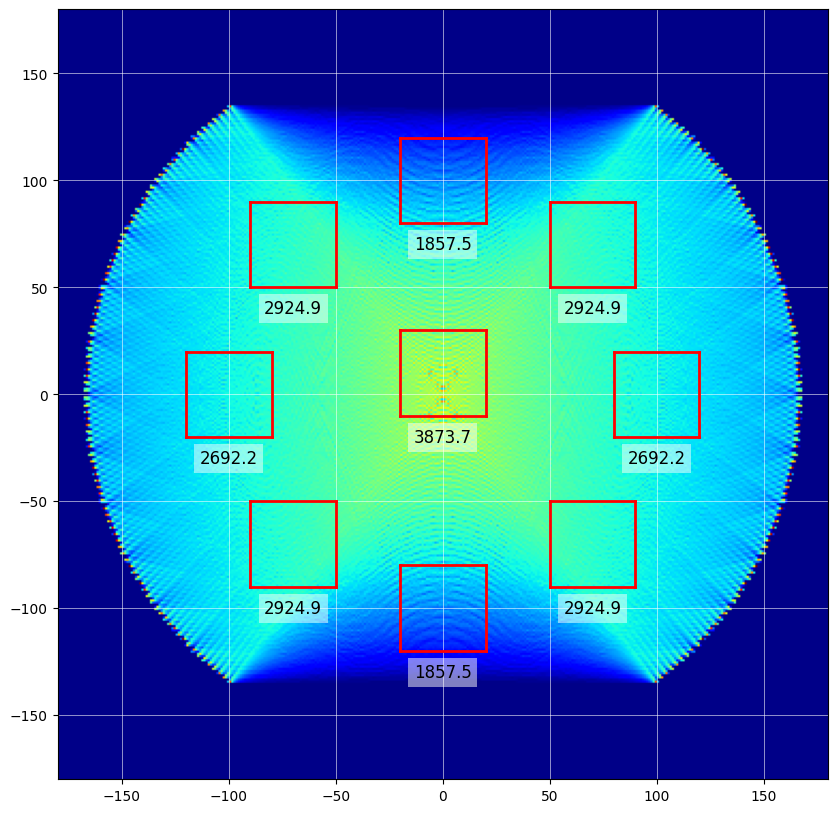

In [65]:
img = img1
plt.figure(figsize=(10, 10))
plt.imshow(img, extent=[-180, 180, -180, 180], cmap = 'jet')
centers = [(0, 10), (0, 100), (-70, 70), (-100, 0), (-70, -70), (0, -100), (70, -70), (100, 0), (70, 70)]
s = 40
sens1 = []
for x, y in centers:    
    print(np.sum(img[x + 180 - s//2:x + 180 + s//2, y + 180 - s//2:y + 180 + s//2]))
    plt.plot([x - s/2, x + s/2], [y - s/2, y - s/2], 'r-', linewidth=2)
    plt.plot([x + s/2, x + s/2], [y - s/2, y + s/2], 'r-', linewidth=2)
    plt.plot([x + s/2, x - s/2], [y + s/2, y + s/2], 'r-', linewidth=2)
    plt.plot([x - s/2, x - s/2], [y + s/2, y - s/2], 'r-', linewidth=2)
    plt.text(
        x, y - s/2 - 10,
        f'{np.sum(img[y + 180-s//2:y + 180+s//2, x + 180-s//2:x + 180+s//2]):.1f}',
        fontsize=12, ha='center', va='center',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')
    )
    sens1.append(np.sum(img[y + 180-s//2:y + 180+s//2, x + 180-s//2:x + 180+s//2]))
plt.grid(True, color='white', linewidth=0.4)
plt.show()

3462.121557022536
2584.145231049397
3073.378101525154
2479.3535169587985
3062.0077395857043
2624.0951513771906
3016.2189847484633
2485.192351468245
3059.8565900295926


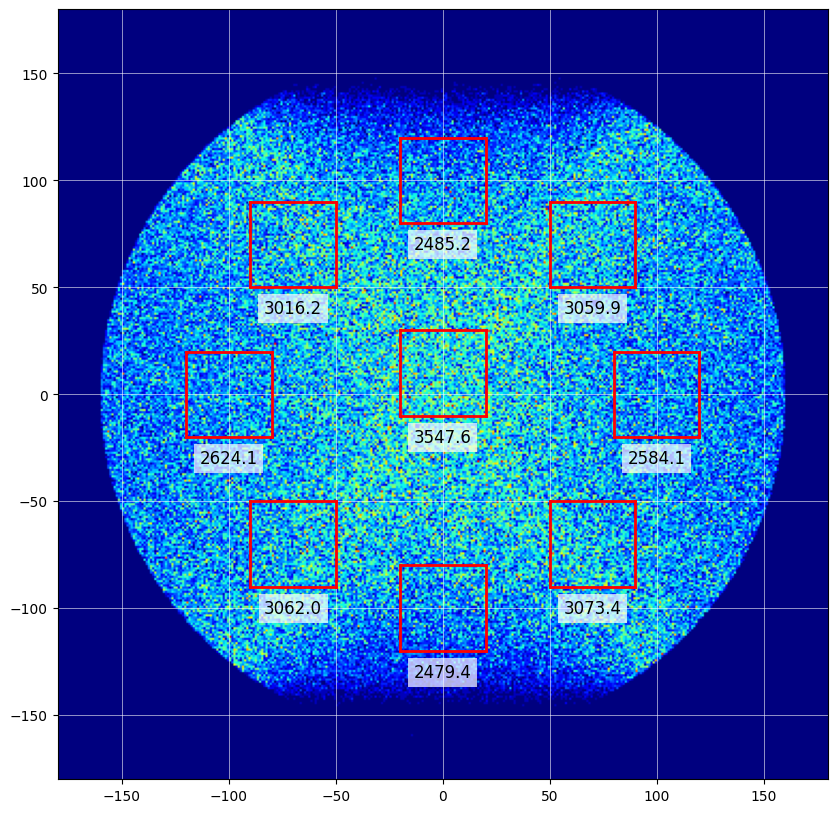

In [66]:
img = img2
plt.figure(figsize=(10, 10))
plt.imshow(img, extent=[-180, 180, -180, 180], cmap = 'jet')
centers = [(0, 10), (0, 100), (-70, 70), (-100, 0), (-70, -70), (0, -100), (70, -70), (100, 0), (70, 70)]
sens2 = []
for x, y in centers:    
    print(np.sum(img[x + 180 - s//2:x + 180 + s//2, y + 180 - s//2:y + 180 + s//2]))
    plt.plot([x - s/2, x + s/2], [y - s/2, y - s/2], 'r-', linewidth=2)
    plt.plot([x + s/2, x + s/2], [y - s/2, y + s/2], 'r-', linewidth=2)
    plt.plot([x + s/2, x - s/2], [y + s/2, y + s/2], 'r-', linewidth=2)
    plt.plot([x - s/2, x - s/2], [y + s/2, y - s/2], 'r-', linewidth=2)
    plt.text(
        x, y - s/2 - 10,
        f'{np.sum(img[y + 180-s//2:y + 180+s//2, x + 180-s//2:x + 180+s//2]):.1f}',
        fontsize=12, ha='center', va='center',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
    )
    sens2.append(np.sum(img[y + 180-s//2:y + 180+s//2, x + 180-s//2:x + 180+s//2]))
plt.grid(True, color='white', linewidth=0.4)
plt.show()

In [87]:
sens1, sens2 = np.array(sens1), np.array(sens2)
print(sens1 / sens2)
vals = np.array([1.236, 1.726, 1.458, 1.347, 1.456, 1.669, 1.453, 1.357, 1.440])
print(vals * sens1 / sens2)

[1. 1. 1. 1. 1. 1. 1. 1. 1.]
[1.236 1.726 1.458 1.347 1.456 1.669 1.453 1.357 1.44 ]


0.0 1.284682


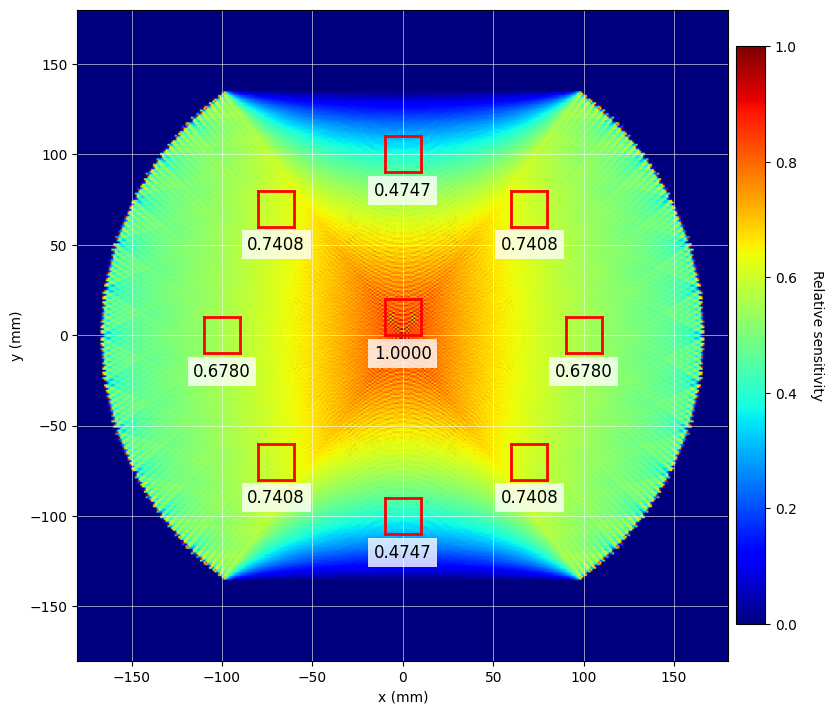

In [44]:
writeupdir = '/home/kale-chen/Documents/PET/Sensitivity Normalization/writeup/plots/sensimgs'
img1 = np.fromfile(os.path.join('sensimgs/sensjosephbipartite.img'), dtype = np.float32).reshape(360, 360, 110, order = 'F')
c, s = plot_sens(img1, centers, savedir = writeupdir + '/sensjosephbipartite.pdf')

0.0 1.0


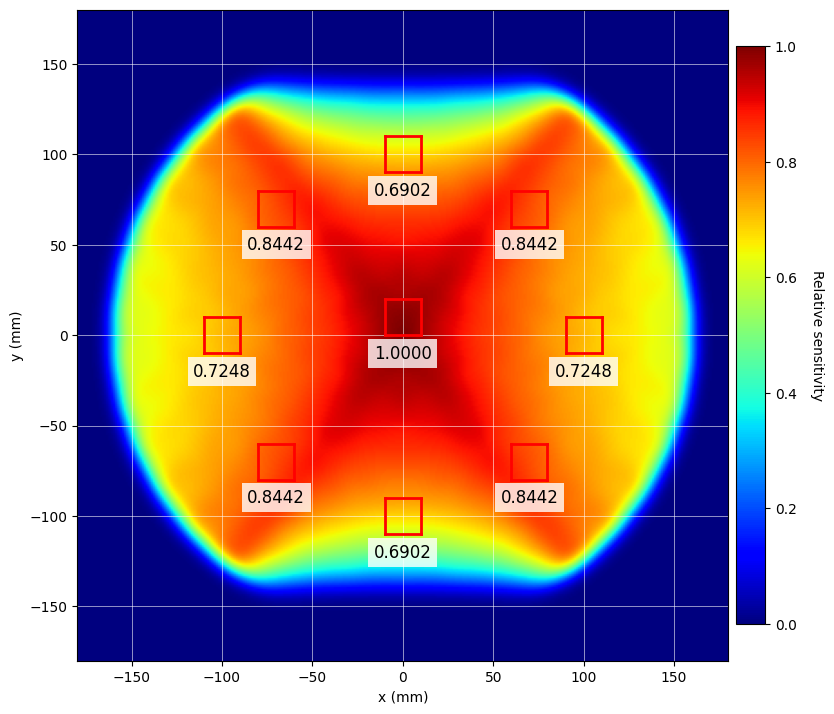

In [46]:
img2 = np.fromfile(os.path.join('sensimgs/mc3d.bin'), dtype = np.int16).reshape(360, 360, 110)
img2 = img2 + img2[::-1,:,:] + img2[:,::-1,:] + img2[::-1,::-1,:] + img2[:,:,::-1] + img2[::-1,:,::-1] + img2[:,::-1,::-1] + img2[::-1,::-1,::-1]
c, s = plot_sens(img2, centers, gauss_sigma =5, savedir = writeupdir + '/mc3dconv5.pdf')

In [475]:
sens1, sens2 = np.array(sens1), np.array(sens2)
#rint(np.round(sens1 / sens2, 4))
vals = np.array([0.1224, 0.1583, 0.1379, 0.1295, 0.1336, 0.1541, 0.1375, 0.1336, 0.1350])
vals = np.array([1.1285, 1.5475, 1.2813, 1.1710, 1.2402, 1.4907, 1.2538, 1.1776, 1.2490]) / 1.1285
vals = np.array([11.181179, 15.133114, 12.6242895, 11.987795, 12.65567, 15.240318, 12.689725, 11.884045, 12.455812]) / 11.181179
print(np.round(vals, 4))
print(np.round(sens1, 4))
print(np.round(sens2, 4))
print(np.round(sens1 / sens2, 4))
print(np.round(vals * sens1, 4))
print(np.round(vals * sens1 / sens2, 4))
print(np.std(vals) / np.mean(vals), np.std(vals * sens1 / sens2) / np.mean(vals * sens1 / sens2))

[1.     1.3534 1.1291 1.0721 1.1319 1.363  1.1349 1.0629 1.114 ]
[1.     0.514  0.7418 0.6831 0.7412 0.5051 0.7586 0.6987 0.7574]
[1.     0.7147 0.8272 0.7255 0.8423 0.7126 0.8648 0.7428 0.8542]
[1.     0.7192 0.8968 0.9415 0.8799 0.7088 0.8772 0.9406 0.8867]
[1.     0.6956 0.8376 0.7324 0.8389 0.6884 0.861  0.7426 0.8438]
[1.     0.9734 1.0125 1.0095 0.996  0.9661 0.9956 0.9997 0.9878]
0.10245082483033952 0.014623870963842996


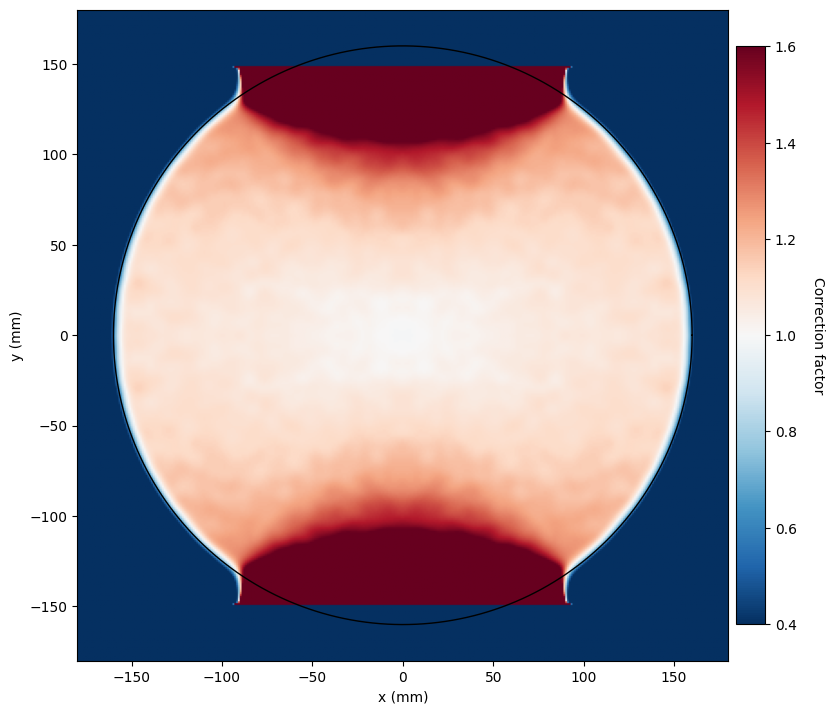

In [ ]:
img1 = np.fromfile(os.path.join('sensimgs/sensjosephbipartite.img'), dtype = np.float32).reshape(360, 360, 110, order = 'F')
img2 = np.fromfile(os.path.join('sensimgs/mc3d.bin'), dtype = np.int16).reshape(360, 360, 110)
img2 = img2.astype(np.float32)
img2 = img2 + img2[::-1,:,:] + img2[:,::-1,:] + img2[::-1,::-1,:] + img2[:,:,::-1] + img2[::-1,:,::-1] + img2[:,::-1,::-1] + img2[::-1,::-1,::-1]
img1 = gaussian_filter(img1, sigma=3.2)
img2 = gaussian_filter(img2, sigma=3.2)
img1 = img1 / np.mean(img1[180-10:180+10, 180-10:180+10, 55-10:55+10])
img2 = img2 / np.mean(img2[180-10:180+10, 180-10:180+10, 55-10:55+10])
img1[img1 == 0] = 1
correction = img2/img1
#correction = gaussian_filter(correction, sigma=2)
plotcorrection = np.sum(correction, axis = 2).T
plotcorrection = plotcorrection / np.mean(plotcorrection[180-10:180+10, 180-10:180+10])
plt.figure(figsize=(10, 10))
plt.imshow(plotcorrection, extent=[-180, 180, -180, 180], cmap = 'RdBu_r', vmin = 0.4, vmax = 1.6)
theta = np.linspace(0, 2*np.pi, 500)
r = 160
x_circle = r * np.cos(theta)
y_circle = r * np.sin(theta)
plt.plot(x_circle, y_circle, color = 'black', linewidth=1)
cbar = plt.colorbar(shrink = 0.75, label = 'Correction factor', pad = 0.01)
cbar.set_label('Correction factor', rotation=270, labelpad=20)
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.savefig(os.path.join(writeupdir, 'correction.pdf'), dpi = 300, bbox_inches = 'tight')
plt.show()

0.0 1.0


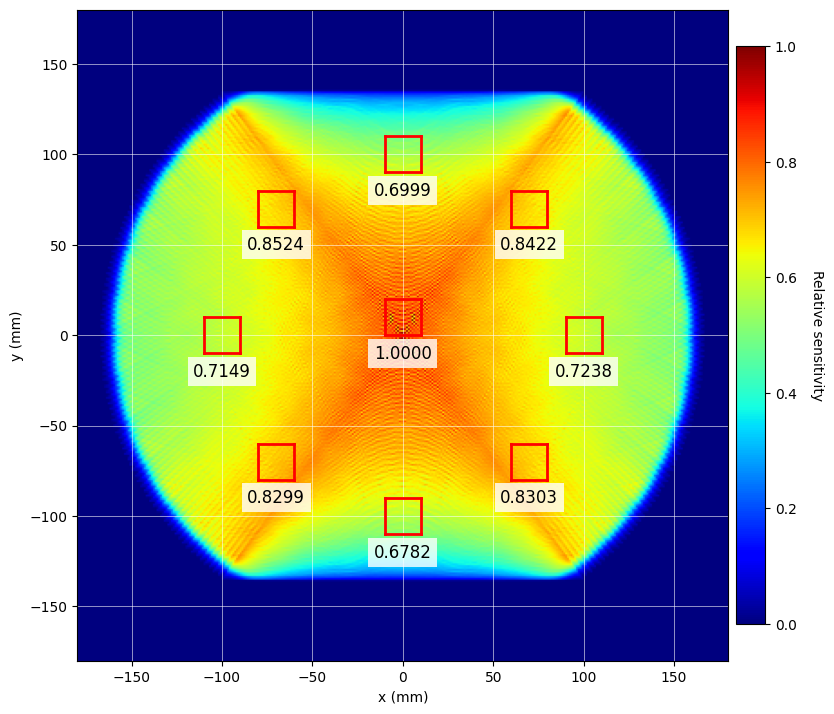

In [49]:
img3 = np.fromfile(os.path.join('sensimgs/sensjosephbipartiten5.img'), dtype = np.float32).reshape(360, 360, 110, order = 'F')
correctedimg = img3 * correction
#correctedimg[250:300, 120:170, 45:65] = 1
c, s = plot_sens(correctedimg, centers, savedir = writeupdir + '/correctedimg.pdf')
#correctedimg = np.flip(np.flip(correctedimg, axis = 1), axis = 2)
correctedimg.astype(np.float32).ravel(order='F').tofile('sensimgs/correctedimg.img')

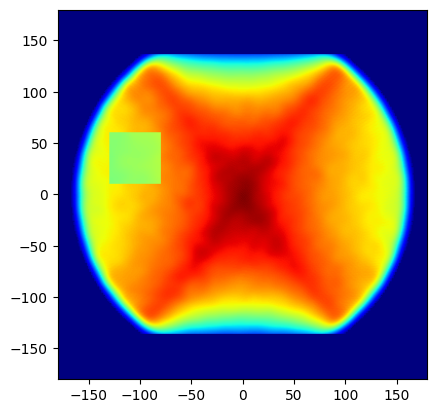

In [404]:
plt.imshow(np.sum(correctedimg, axis = 2).T, extent=[-180, 180, -180, 180], cmap = 'jet')

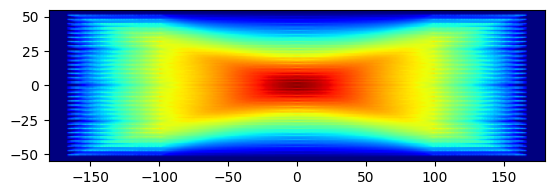

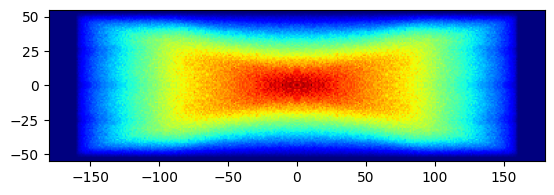

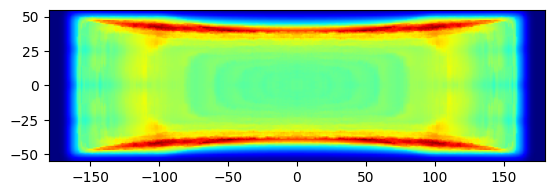

In [521]:
img1 = np.fromfile(os.path.join('sensimgs/sensjosephbipartite.img'), dtype = np.float32).reshape(360, 360, 110, order = 'F')
plt.imshow(np.sum(img1, axis = 1).T, extent=[-180, 180, -55, 55], cmap = 'jet')
plt.show()
img2 = np.fromfile(os.path.join('sensimgs/mc3d.bin'), dtype = np.int16).reshape(360, 360, 110)
img2 = img2 + img2[::-1,:,:] + img2[:,::-1,:] + img2[::-1,::-1,:] + img2[:,:,::-1] + img2[::-1,:,::-1] + img2[:,::-1,::-1] + img2[::-1,::-1,::-1]
plt.imshow(np.sum(img2, axis = 1).T, extent=[-180, 180, -55, 55], cmap = 'jet')
plt.show()
img1 = gaussian_filter(img1, sigma=3)
img2 = gaussian_filter(img2, sigma=3)
img2 = img2 / np.mean(img2)
img2[img2 == 0] = 1
imgr = img1 / img2
plt.imshow(np.sum(imgr, axis = 1).T, extent=[-180, 180, -55, 55], cmap = 'jet')
plt.show()